# DATA102 Project - Case Study

**Group 1**
- ANTIADO LEONNA FELICIANO
- CUEVAS GHEANN CHRISTIE MEDIODIA
- DIVINA PRECIOUS MAE MERCADO
- MARTINEZ MIKAELLA KAYE ANG
- SISON AARON JOSHUA ESTACIO

## Phase 1

### 1. Dataset Description

The dataset is a subset of the United States Department of Education College Scorecard, a public database that reports institutional characteristics, costs, student outcomes, and debt for postsecondary institutions across the country. The Scorecard was created to help students and families make informed decisions about higher education by providing transparent, comparable data on costs and expected earnings.

The data are collected through federal reporting requirements. Institutions that participate in Title IV federal student aid programs must report enrollment, completion, tuition, and financial aid data to the Department of Education. Earnings outcomes are drawn from de-identified tax records matched to former students through the Treasury Department, providing a reliable measure of labour-market returns. The collection process imposes standardised definitions across institutions, which strengthens internal comparability, but the earnings data are limited to students who received federal financial aid and whose tax records could be matched. This means the earnings figures may not represent all graduates and may understate outcomes for students from higher-income families who did not receive aid.

The dataset used in this analysis contains 6,273 rows and 24 columns. Each row represents one postsecondary institution identified by a unique unit identifier. The columns capture institutional identity, admissions selectivity, demographic designations, tuition, student debt, and post-graduation earnings. The key variables for this study are in-state tuition, median earnings ten years after entry, institutional control type, median graduate debt, and undergraduate enrollment. The full list of variables, including those not used in the study, is available in the College Scorecard data dictionary.

#### Variables

- **UNITID** — Unique institution identifier assigned by the Department of Education
- **INSTNM** — Institution name
- **CITY** — City
- **STABBR** — Two-letter state abbreviation
- **PREDDEG** — Predominant degree awarded (0 = non-degree-granting, 4 = graduate-focused)
- **CONTROL** — Ownership classification (1 = public, 2 = private nonprofit, 3 = private for-profit)
- **LOCALE** — Urban-centric locale code
- **HBCU** — Historically Black College or University flag (1 = yes)
- **PBI** — Predominantly Black Institution flag (1 = yes)
- **ANNHI** — Alaska Native or Native Hawaiian Serving Institution flag
- **TRIBAL** — Tribal College or University flag
- **AANAPII** — Asian American Native American Pacific Islander Serving Institution flag
- **HSI** — Hispanic-Serving Institution flag
- **NANTI** — Native American Non-Tribal Institution flag
- **MENONLY** — Men-only institution flag
- **WOMENONLY** — Women-only institution flag
- **RELAFFIL** — Religious affiliation code
- **ADM_RATE** — Proportion of applicants admitted
- **SAT_AVG** — Average SAT score of admitted students
- **UGDS** — Total undergraduate enrollment
- **TUITIONFEE_IN** — Published in-state tuition and fees
- **TUITIONFEE_OUT** — Published out-of-state tuition and fees
- **GRAD_DEBT_MDN** — Median debt of graduates (federal and private loans)
- **MD_EARN_WNE_P10** — Median earnings of former students ten years after entry, among those working and not enrolled

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual aesthetics
sns.set_theme(style="whitegrid")
from scipy import stats
import statsmodels.api as sm
from IPython.display import display


### 2. Data Cleaning

The dataset contains 6,273 institutions across 24 variables. We restrict analysis to five variables central to the research question: in-state tuition, median post-graduation earnings, median graduate debt, institutional control type, and undergraduate enrollment.

Two variables were excluded. SAT average scores are missing for 83.5% of institutions and admission rates for 69.6%. Imputing values for the majority of observations would introduce bias and undermine the validity of downstream inferences. Institutions reporting $0 in-state tuition were also removed. While some institutions legitimately charge no tuition, the investment-return framing of this study requires a positive cost baseline.

The cleaning pipeline handles six issues. Privacy-suppressed values in the graduate debt column are coerced to NaN and dropped. Rows missing the target variable or primary predictor are removed. Undergraduate enrollment nulls are imputed with per-sector medians, a more principled approach than a global median given the wide enrollment differences across sectors. Duplicate institution identifiers are detected and removed. Outliers in earnings are trimmed symmetrically via the IQR method; tuition outliers are trimmed per sector, since tuition distributions differ dramatically by control type. A human-readable sector label is created for readability.

In [2]:
# DATA CLEANING PIPELINE
# Step 1: Load the dataset
df_raw = pd.read_csv('data/final_datasets/College_Scorecard_Subset.csv', low_memory=False)
initial_count = len(df_raw)

# Step 2: Print raw shape and null counts for variables of interest
target_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'CONTROL', 'UGDS']
print(f"Raw dataset shape: {df_raw.shape}")
print("\nNull counts in variables of interest:")
print(df_raw[target_vars].isnull().sum())

# Step 3: GRAD_DEBT_MDN — convert 'PS' (PrivacySuppressed) strings to NaN
n_before = df_raw['GRAD_DEBT_MDN'].notna().sum()
df_raw['GRAD_DEBT_MDN'] = pd.to_numeric(df_raw['GRAD_DEBT_MDN'], errors='coerce')
n_after = df_raw['GRAD_DEBT_MDN'].notna().sum()
suppressed_dropped = n_before - n_after
print(f"\nGRAD_DEBT_MDN: {suppressed_dropped} PrivacySuppressed values coerced to NaN (dtype now: {df_raw['GRAD_DEBT_MDN'].dtype})")
print(f"GRAD_DEBT_MDN null after coercion: {df_raw['GRAD_DEBT_MDN'].isnull().sum()}")

# Step 4: Drop rows where MD_EARN_WNE_P10 or TUITIONFEE_IN is null
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['MD_EARN_WNE_P10', 'TUITIONFEE_IN'])
null_target_rows = count_before - len(df_raw)
print(f"\nDropped {null_target_rows} rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: {len(df_raw)}")

# Step 5: Drop rows where TUITIONFEE_IN == 0
count_before = len(df_raw)
zero_tuition_rows = (df_raw['TUITIONFEE_IN'] == 0).sum()
df_raw = df_raw[df_raw['TUITIONFEE_IN'] > 0]
print(f"Dropped {zero_tuition_rows} rows with $0 in-state tuition. Remaining: {len(df_raw)}")

# Step 6: Drop rows where GRAD_DEBT_MDN is null after coercion
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['GRAD_DEBT_MDN'])
debt_null_rows = count_before - len(df_raw)
print(f"Dropped {debt_null_rows} rows with null GRAD_DEBT_MDN. Remaining: {len(df_raw)}")

# Step 7: Impute UGDS nulls with per-CONTROL-group median
ugds_null_before = df_raw['UGDS'].isnull().sum()
df_raw['UGDS'] = df_raw.groupby('CONTROL')['UGDS'].transform(lambda x: x.fillna(x.median()))
ugds_null_after = df_raw['UGDS'].isnull().sum()
print(f"\nUGDS nulls imputed with per-CONTROL-group median: {ugds_null_before} -> {ugds_null_after}")

# Step 8: Check for and drop duplicate UNITID values
dup_unitid_count = df_raw['UNITID'].duplicated().sum()
if dup_unitid_count > 0:
    df_raw = df_raw.drop_duplicates(subset='UNITID', keep='first')
print(f"Duplicate UNITID rows found and dropped: {dup_unitid_count}. Remaining: {len(df_raw)}")

# Step 9: Create CONTROL_LABEL column for readability
control_map = {1: 'Public', 2: 'Private Nonprofit', 3: 'For-Profit'}
df_raw['CONTROL_LABEL'] = df_raw['CONTROL'].map(control_map)
print(f"\nCONTROL_LABEL created. Value counts:")
print(df_raw['CONTROL_LABEL'].value_counts())

# Step 10: Symmetric IQR outlier removal on MD_EARN_WNE_P10 (both tails)
count_before = len(df_raw)
Q1_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.25)
Q3_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.75)
IQR_earn = Q3_earn - Q1_earn
lower_earn = Q1_earn - 1.5 * IQR_earn
upper_earn = Q3_earn + 1.5 * IQR_earn
df_raw = df_raw[(df_raw['MD_EARN_WNE_P10'] >= lower_earn) & (df_raw['MD_EARN_WNE_P10'] <= upper_earn)]
earn_outlier_rows = count_before - len(df_raw)
print(f"\nSymmetric IQR on MD_EARN_WNE_P10: [{lower_earn:.0f}, {upper_earn:.0f}]. Dropped {earn_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 11: Per-CONTROL-group IQR outlier removal on TUITIONFEE_IN
count_before = len(df_raw)
def filter_tuition_outliers(group):
    Q1 = group['TUITIONFEE_IN'].quantile(0.25)
    Q3 = group['TUITIONFEE_IN'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['TUITIONFEE_IN'] >= lower) & (group['TUITIONFEE_IN'] <= upper)]
df_raw = df_raw.groupby('CONTROL_LABEL', group_keys=False)[df_raw.columns].apply(filter_tuition_outliers, include_groups=False)
tuit_outlier_rows = count_before - len(df_raw)
print(f"Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped {tuit_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 12: Transformation log — summary of rows removed
final_count = len(df_raw)
total_removed = initial_count - final_count
print("TRANSFORMATION LOG")
print(f"Initial rows:                     {initial_count:>6d}")
print(f"  Removed (null target/predictor): {null_target_rows:>6d}")
print(f"  Removed ($0 tuition):            {zero_tuition_rows:>6d}")
print(f"  Removed (null GRAD_DEBT_MDN):    {debt_null_rows:>6d}")
print(f"  Removed (duplicate UNITID):      {dup_unitid_count:>6d}")
print(f"  Removed (earnings outliers):     {earn_outlier_rows:>6d}")
print(f"  Removed (tuition outliers):      {tuit_outlier_rows:>6d}")
print(f"  Total rows removed:              {total_removed:>6d}")
print(f"Final rows:                        {final_count:>6d}")

# Step 13: Final cleaned DataFrame
df_cleaned = df_raw.reset_index(drop=True)
print(f"\nFinal df_cleaned shape: {df_cleaned.shape}")
print("\nNull counts in target variables (should all be zero):")
print(df_cleaned[target_vars].isnull().sum())
print(f"\nTUITIONFEE_IN min: ${df_cleaned['TUITIONFEE_IN'].min():.0f}")
print(f"Duplicate UNITID check: {df_cleaned['UNITID'].duplicated().sum()}")
df_cleaned.head()


Raw dataset shape: (6273, 24)

Null counts in variables of interest:
TUITIONFEE_IN      2661
MD_EARN_WNE_P10    1146
GRAD_DEBT_MDN       268
CONTROL               0
UGDS                795
dtype: int64

GRAD_DEBT_MDN: 1228 PrivacySuppressed values coerced to NaN (dtype now: float64)
GRAD_DEBT_MDN null after coercion: 1496

Dropped 2915 rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: 3358
Dropped 1 rows with $0 in-state tuition. Remaining: 3357
Dropped 296 rows with null GRAD_DEBT_MDN. Remaining: 3061

UGDS nulls imputed with per-CONTROL-group median: 257 -> 0
Duplicate UNITID rows found and dropped: 0. Remaining: 3061

CONTROL_LABEL created. Value counts:
CONTROL_LABEL
Public               1475
Private Nonprofit    1173
For-Profit            413
Name: count, dtype: int64

Symmetric IQR on MD_EARN_WNE_P10: [11818, 84278]. Dropped 105 rows. Remaining: 2956
Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped 62 rows. Remaining: 2894
TRANSFORMATION LOG
Initial rows:                  

,UNITID,INSTNM,CITY,STABBR,PREDDEG,CONTROL,LOCALE,HBCU,PBI,ANNHI,...,WOMENONLY,RELAFFIL,ADM_RATE,SAT_AVG,UGDS,TUITIONFEE_IN,TUITIONFEE_OUT,GRAD_DEBT_MDN,MD_EARN_WNE_P10,CONTROL_LABEL
0,101116,South University-Montgomery,Montgomery,AL,3,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,299.0,18145.0,18145.0,26123.0,34421.0,For-Profit
1,102845,Charter College,Anchorage,AK,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2157.0,18375.0,18375.0,14176.0,35504.0,For-Profit
2,110219,Bryan University,Tempe,AZ,1,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2506.0,12219.0,12219.0,20000.0,40283.0,For-Profit
3,110468,Alliant International University-San Diego,San Diego,CA,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.0000,NaN,391.0,14304.0,14304.0,12878.0,66666.0,For-Profit
4,112394,University of Silicon Valley,San Jose,CA,3,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.5118,NaN,455.0,22480.0,22480.0,31000.0,51017.0,For-Profit


### Descriptive Statistics

We establish a baseline through summary statistics stratified by institutional control type. Panel A reports the sector composition of the cleaned dataset. Panel B presents measures of central tendency and dispersion for the four continuous variables: in-state tuition, median post-graduation earnings, median graduate debt, and undergraduate enrollment.

The descriptive statistics reveal pronounced differences across the three institutional sectors. Private nonprofit institutions charge the highest mean tuition, followed by for-profit and public institutions. Public universities charge roughly one-fifth of the nonprofit level, yet produce among the highest median post-graduation earnings alongside private nonprofits. For-profit institutions show the lowest mean and median earnings despite charging tuition that falls between public and nonprofit levels. Earnings dispersion is widest among private nonprofits, while undergraduate enrollment varies most in the public sector. These disparities motivate a closer examination of whether the tuition-earnings relationship differs by institutional control type.


In [3]:
# DESCRIPTIVE STATISTICS
# Panel A: CONTROL counts and percentages
control_counts = df_cleaned['CONTROL_LABEL'].value_counts()
control_pct = df_cleaned['CONTROL_LABEL'].value_counts(normalize=True).sort_index() * 100

panel_a = pd.DataFrame({
    'Count': control_counts,
    'Percent': control_pct.round(1).astype(str) + '%'
})
panel_a.index.name = 'CONTROL_LABEL'

print("PANEL A: Institution Counts by Control Type")
display(panel_a)
print(f"\nTotal institutions: {len(df_cleaned)}")

# Panel B: Multi-index table — 4 variables x 4 statistics, split by CONTROL + Overall
summary_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'UGDS']
var_labels = {
    'TUITIONFEE_IN': 'In-State Tuition',
    'MD_EARN_WNE_P10': 'Median Earnings',
    'GRAD_DEBT_MDN': 'Median Graduate Debt',
    'UGDS': 'Undergraduate Enrollment'
}

# Build per-group statistics
groups = ['Public', 'Private Nonprofit', 'For-Profit']
stat_funcs = {
    'Mean': 'mean',
    'Median': 'median',
    'Std': 'std',
    'IQR': lambda x: x.quantile(0.75) - x.quantile(0.25)
}

panel_b_data = {}
for var in summary_vars:
    panel_b_data[var] = {}
    for stat_name, stat_fn in stat_funcs.items():
        row = {}
        for grp in groups:
            subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp][var]
            row[grp] = subset.agg(stat_fn)
        # Overall
        row['Overall'] = df_cleaned[var].agg(stat_fn)
        panel_b_data[var][stat_name] = row

# Format as multi-index DataFrame
rows = []
for var in summary_vars:
    for stat_name in stat_funcs.keys():
        row_data = panel_b_data[var][stat_name]
        rows.append({
            'Variable': var_labels[var],
            'Statistic': stat_name,
            **row_data
        })

panel_b = pd.DataFrame(rows).set_index(['Variable', 'Statistic'])

# Build display copy with formatted strings (pandas 3.x forbids mixed dtypes in-place)
panel_b_display = panel_b.copy().astype(object)
dollar_vars = ['In-State Tuition', 'Median Earnings', 'Median Graduate Debt']
for var_label in dollar_vars:
    for stat in stat_funcs.keys():
        for col in groups + ['Overall']:
            if (var_label, stat) in panel_b_display.index:
                val = panel_b_display.loc[(var_label, stat), col]
                if pd.notna(val):
                    panel_b_display.loc[(var_label, stat), col] = f"${val:,.0f}"

for stat in stat_funcs.keys():
    for col in groups + ['Overall']:
        if ('Undergraduate Enrollment', stat) in panel_b_display.index:
            val = panel_b_display.loc[('Undergraduate Enrollment', stat), col]
            if pd.notna(val):
                panel_b_display.loc[('Undergraduate Enrollment', stat), col] = f"{float(val):,.0f}"

print("\nPANEL B: Descriptive Statistics by Control Type")
display(panel_b_display)


PANEL A: Institution Counts by Control Type


,Count,Percent
CONTROL_LABEL,,
For-Profit,360,12.4%
Private Nonprofit,1104,38.1%
Public,1430,49.4%



Total institutions: 2894

PANEL B: Descriptive Statistics by Control Type


Public Private Nonprofit For-Profit  \
Variable                 Statistic                                         
In-State Tuition         Mean        $6,786           $33,370    $15,934   
                         Median      $5,981           $33,928    $16,326   
                         Std         $3,572           $16,069     $3,626   
                         IQR         $4,664           $23,741     $4,225   
Median Earnings          Mean       $45,993           $52,375    $38,274   
                         Median     $43,466           $52,198    $37,480   
                         Std        $10,269           $13,368    $10,132   
                         IQR        $12,918           $17,056    $11,419   
Median Graduate Debt     Mean       $14,594           $22,974    $18,876   
                         Median     $12,250           $24,517    $18,668   
                         Std         $6,148            $5,087     $9,792   
                         IQR        $10,387            $4,948    $13,743   
Undergraduate Enrollment Mean         6,758             2,196      1,355   
                         Median       3,953             1,223        396   
                         Std          8,294             7,657      5,795   
                         IQR          6,056             1,356        310   

                                    Overall  
Variable                 Statistic           
In-State Tuition         Mean       $18,065  
                         Median     $12,221  
                         Std        $16,101  
                         IQR        $19,101  
Median Earnings          Mean       $47,468  
                         Median     $45,378  
                         Std        $12,400  
                         IQR        $16,696  
Median Graduate Debt     Mean       $18,324  
                         Median     $19,500  
                         Std         $7,457  
                         IQR        $13,684  
Undergraduate Enrollment Mean         4,346  
                         Median       1,792  
                         Std          8,140  
                         IQR          3,454

### 3. Exploratory Data Analysis

We pose six questions that move from univariate description to joint and contextual relationships, building toward the research question.

1. What is the distribution of post-graduation earnings, and how does it vary by institution control type?
2. What is the distribution of in-state tuition across institution types, and what proportion of each sector charges above the national median?
3. What patterns emerge when examining tuition and earnings jointly? Do institution types form distinct clusters in the tuition-earnings space?
4. What is the relationship between in-state tuition and median graduate debt? How does debt compare to earnings across sectors?
5. Controlling for sector, how does admission selectivity relate to post-graduation earnings? Does the tuition-earnings correlation persist among similarly selective institutions?
6. Within each institutional control type, do minority-serving institutions show systematically different tuition and earnings profiles compared to non-minority-serving institutions?

,Mean,Median,Std,IQR,Skewness
CONTROL_LABEL,,,,,
For-Profit,38274.0,37480.0,10132.0,11419.0,1.0
Private Nonprofit,52375.0,52198.0,13368.0,17056.0,0.0
Public,45993.0,43466.0,10269.0,12918.0,1.0


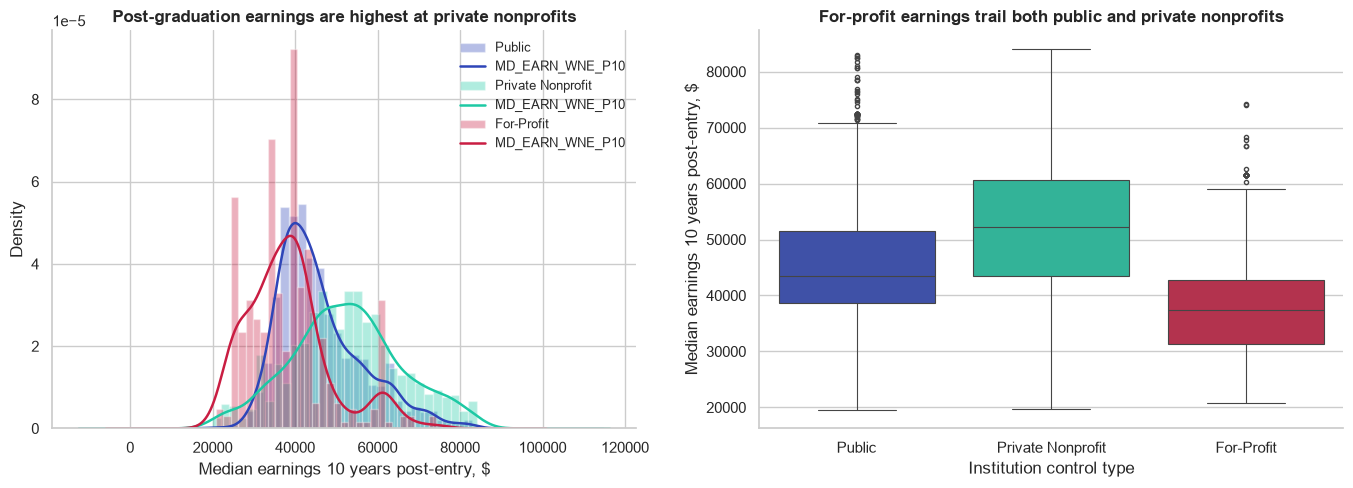

,Mean,Median,Std,IQR,Pct_Above_Overall_Median
CONTROL_LABEL,,,,,
For-Profit,15934.0,16326.0,3626.0,4225.0,84.4%
Private Nonprofit,33370.0,33928.0,16069.0,23741.0,91.2%
Public,6786.0,5981.0,3572.0,4664.0,9.5%


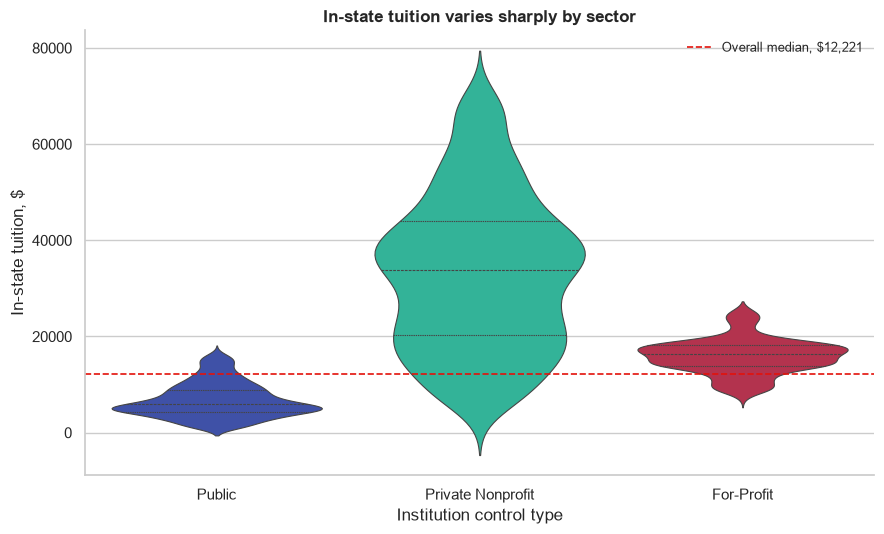

,Spearman r,p-value
Public,0.6286,4.29e-158
Private Nonprofit,0.5874,2.14e-103
For-Profit,0.3352,6.68e-11
Overall,0.4641,1.53e-154


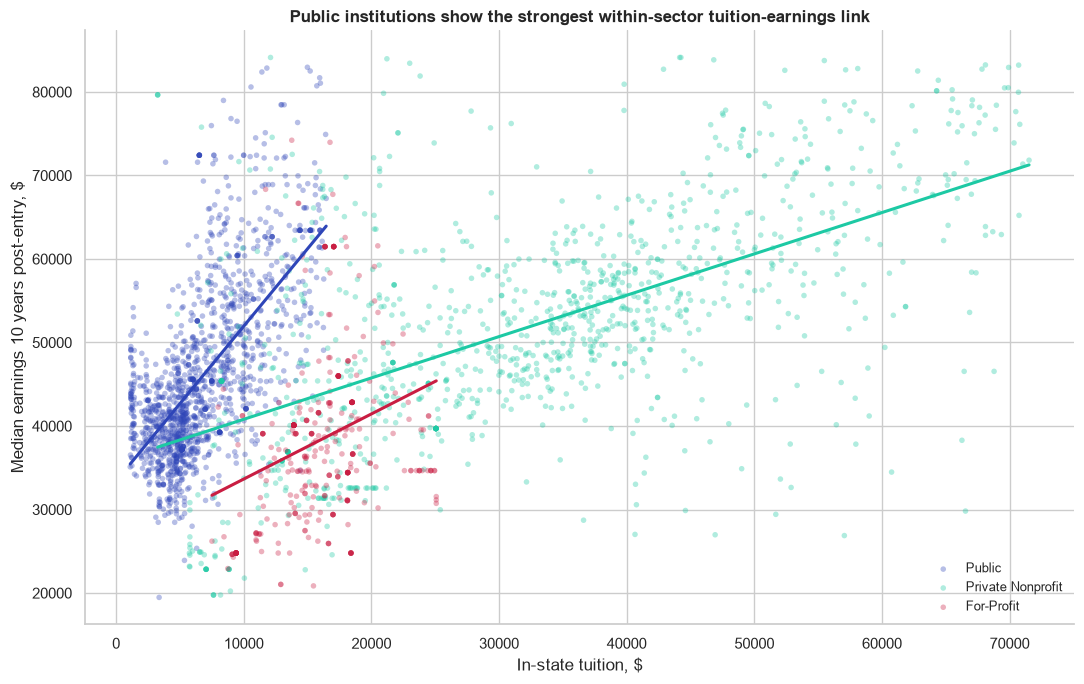

,Spearman r (Tuition vs Debt),p-value
Public,0.7292,1.41e-237
Private Nonprofit,0.2739,1.87e-20
For-Profit,0.1114,3.46e-02


,Median Ratio
CONTROL_LABEL,
For-Profit,0.4323
Private Nonprofit,0.4531
Public,0.2896


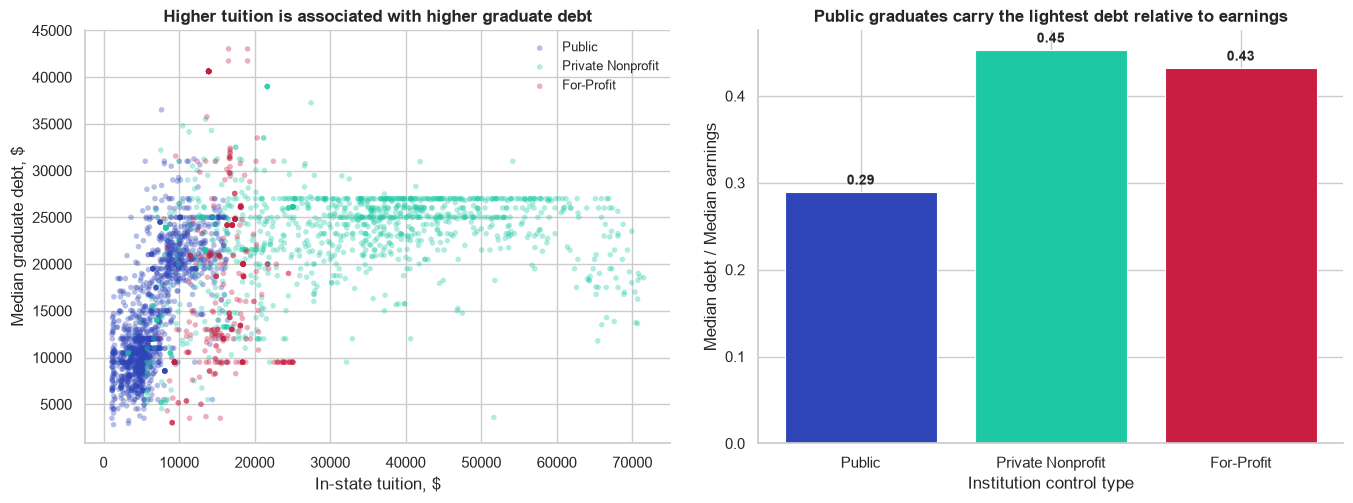

In [4]:
# Q1: Earnings Distribution by Sector
q1_stats = df_cleaned.groupby('CONTROL_LABEL')['MD_EARN_WNE_P10'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Skewness='skew'
).round(0)
display(q1_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Q1 palette: Public=Chicago 45, Nonprofit=Hong Kong 45, For-Profit=Tokyo 45
q1_colors = {'Public': '#2E45B8', 'Private Nonprofit': '#1DC9A4', 'For-Profit': '#C91D42'}
for label, color in q1_colors.items():
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == label]['MD_EARN_WNE_P10']
    axes[0].hist(subset, bins=30, alpha=0.35, label=label, color=color, density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=1.8)

axes[0].set_title('Post-graduation earnings are highest at private nonprofits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

order = ['Public', 'Private Nonprofit', 'For-Profit']
bp = sns.boxplot(data=df_cleaned, x='CONTROL_LABEL', y='MD_EARN_WNE_P10', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, ax=axes[1], linewidth=0.8, fliersize=3)
axes[1].set_title('For-profit earnings trail both public and private nonprofits', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median earnings 10 years post-entry, $')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

# Q2: Tuition Distribution by Sector
q2_stats = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(0)

overall_median_tuition = df_cleaned['TUITIONFEE_IN'].median()
q2_stats['Pct_Above_Overall_Median'] = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].apply(
    lambda x: (x > overall_median_tuition).mean() * 100
).round(1).astype(str) + '%'
display(q2_stats)

plt.figure(figsize=(9, 5.5))
sns.violinplot(data=df_cleaned, x='CONTROL_LABEL', y='TUITIONFEE_IN', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, inner='quartile', linewidth=0.8)
plt.axhline(y=overall_median_tuition, color='#E3120B', linestyle='--', linewidth=1.2,
    label=f'Overall median, ${overall_median_tuition:,.0f}')
plt.title('In-state tuition varies sharply by sector', fontsize=12, fontweight='bold')
plt.xlabel('Institution control type')
plt.ylabel('In-state tuition, $')
plt.legend(frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Q3: Joint Tuition-Earnings Relationship
overall_r, overall_p = stats.spearmanr(df_cleaned['TUITIONFEE_IN'], df_cleaned['MD_EARN_WNE_P10'])
per_group_r = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
    per_group_r[grp] = {'Spearman r': round(r, 4), 'p-value': f'{p:.2e}'}

q3_corr_df = pd.DataFrame(per_group_r).T
q3_corr_df.loc['Overall'] = [round(overall_r, 4), f'{overall_p:.2e}']
display(q3_corr_df)

plt.figure(figsize=(11, 7))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    plt.scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
    m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
    x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 80)
    plt.plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2.2, linestyle='-')

plt.title('Public institutions show the strongest within-sector tuition-earnings link', fontsize=12, fontweight='bold')
plt.xlabel('In-state tuition, $')
plt.ylabel('Median earnings 10 years post-entry, $')
plt.legend(title=None, frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Q4: Debt as a Mediating Variable
q4_corr = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'])
    q4_corr[grp] = {'Spearman r (Tuition vs Debt)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q4_corr).T)

df_cleaned['Debt_Earnings_Ratio'] = df_cleaned['GRAD_DEBT_MDN'] / df_cleaned['MD_EARN_WNE_P10']
ratio_summary = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median().round(4)
display(ratio_summary.to_frame('Median Ratio'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    axes[0].scatter(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
axes[0].set_title('Higher tuition is associated with higher graduate debt', fontsize=12, fontweight='bold')
axes[0].set_xlabel('In-state tuition, $')
axes[0].set_ylabel('Median graduate debt, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

ratio_medians = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median()
bars = axes[1].bar(order, [ratio_medians[g] for g in order],
    color=[q1_colors[g] for g in order], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, [ratio_medians[g] for g in order]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
        f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Public graduates carry the lightest debt relative to earnings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median debt / Median earnings')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()
# Q5: Admissions Selectivity and Earnings, Stratified by Sector
df_selective = df_cleaned.dropna(subset=['ADM_RATE']).copy()
df_selective['Selectivity'] = pd.cut(df_selective['ADM_RATE'],
    bins=[0, 0.4, 0.7, 1.0], labels=['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)'])

q5_stats = df_selective.groupby(['CONTROL_LABEL', 'Selectivity'])['MD_EARN_WNE_P10'].agg(
    Count='count', Mean='mean', Median='median'
).round(0)
display(q5_stats)

q5_corr = {}
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
        q5_corr[grp] = {'Spearman r (tuition-earnings)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q5_corr).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
selectivity_order = ['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)']
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        means = subset.groupby('Selectivity', observed=False)['MD_EARN_WNE_P10'].mean()
        axes[0].plot(selectivity_order, [means.get(s, np.nan) for s in selectivity_order],
            'o-', color=q1_colors[grp], linewidth=1.8, markersize=6, label=grp)
axes[0].set_title('Earnings decline with admission rate across all sectors', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Selectivity')
axes[0].set_ylabel('Mean earnings, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=20)

scatter_groups = [g for g in order if g in q5_corr]
for grp in scatter_groups:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    axes[1].scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.3, s=14, label=grp, edgecolors='none')
    if len(subset) > 10:
        m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
        x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 60)
        axes[1].plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2, linestyle='-')
axes[1].set_title('The tuition-earnings link weakens within the reporting subset but persists by sector', fontsize=12, fontweight='bold')
axes[1].set_xlabel('In-state tuition, $')
axes[1].set_ylabel('Median earnings, $')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

# Q6: Minority-Serving Institution Profiles by Sector
msi_cols = ['HBCU', 'PBI', 'HSI', 'ANNHI', 'TRIBAL', 'AANAPII', 'NANTI']
df_cleaned['Any_MSI'] = df_cleaned[msi_cols].max(axis=1)
df_cleaned['MSI_Label'] = df_cleaned['Any_MSI'].map({1.0: 'Minority-serving', 0.0: 'Non-minority-serving'})

msi_counts = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label']).size().unstack(fill_value=0)
display(msi_counts)

q6_stats = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label'])[['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN']].agg(['mean', 'median']).round(0)
q6_stats.columns = ['_'.join(c).strip('_') for c in q6_stats.columns]
display(q6_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
msi_order = ['Non-minority-serving', 'Minority-serving']
bar_width = 0.35
x_pos = np.arange(len(order))

for j, (var, title, fmt) in enumerate([
    ('TUITIONFEE_IN', 'Tuition', 'In-state tuition, $'),
    ('MD_EARN_WNE_P10', 'Earnings', 'Median earnings, $')
]):
    for i, msi_label in enumerate(msi_order):
        subset = df_cleaned[df_cleaned['MSI_Label'] == msi_label]
        medians = [subset[subset['CONTROL_LABEL'] == g][var].median() for g in order]
        offset = (i - 0.5) * bar_width
        axes[j].bar(x_pos + offset, medians, bar_width * 0.9,
            color=[q1_colors[g] for g in order] if msi_label == 'Non-minority-serving' else ['#141F52', '#0E8A6E', '#9E1530'],
            alpha=0.85, label=msi_label, edgecolor='white', linewidth=0.5)
    axes[j].set_title(f'{title}: MSIs show lower figures within each sector', fontsize=12, fontweight='bold')
    axes[j].set_xticks(x_pos)
    axes[j].set_xticklabels(order)
    axes[j].set_ylabel(fmt)
    axes[j].legend(frameon=False, fontsize=9)
    axes[j].spines['top'].set_visible(False)
    axes[j].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()


### 3. Exploratory Data Analysis — Findings

**Q1. Earnings distribution by sector.** The first question examines the distribution of median post-graduation earnings across the three institutional control types. We compute the mean, median, standard deviation, IQR, and skewness for each sector. These measures of central tendency and dispersion reveal whether earnings outcomes are uniformly distributed or concentrated within certain sectors. A histogram with kernel density estimates overlays the three distributions, and side-by-side box plots provide a non-parametric comparison of central tendency and spread.

Private nonprofit institutions report the highest mean and median post-graduation earnings, followed by public institutions. For-profit earnings are visibly lower: their median falls below the interquartile range of both other sectors. Private nonprofits also show the widest earnings dispersion, measured by both standard deviation and IQR. The distributions overlap considerably, meaning that individual institutions within each sector span a wide range of outcomes, but the central tendencies differ sharply. This stratification by sector justifies the research question's focus on whether the tuition-earnings relationship itself varies by control type.

**Q2. Tuition distribution by sector.** The second question mirrors the first but examines in-state tuition rather than earnings. The same summary statistics are computed per sector, and an additional measure is added: the proportion of institutions in each sector whose tuition exceeds the national median. A violin plot displays the full shape of each distribution, with a dashed Economist Red reference line at the overall median.

Tuition distributions are more sharply separated than earnings distributions. Private nonprofits cluster at the highest tuition levels, with over 90% charging above the national median. Public institutions occupy a narrow, low-tuition band with fewer than 10% exceeding the median. For-profit tuition falls between the two, with roughly 84% above the median and a narrower spread than the nonprofit sector. The contrast with Q1 is instructive: public institutions produce competitive earnings from a much lower cost base. This asymmetry — large tuition differences paired with more modest earnings differences — motivates a direct examination of the tuition-earnings relationship in Q3.

**Q3. Joint tuition-earnings relationship.** The third question moves from univariate description to bivariate analysis. Spearman's rank correlation is used rather than Pearson's because the exploratory analysis already suggests non-normality in the earnings distribution. Correlations are computed for the full sample and separately for each sector. A scatter plot displays the joint distribution, with linear regression lines fitted within each sector to visualise the direction and strength of the relationship.

The overall Spearman correlation between tuition and earnings is moderately positive, but this aggregate figure masks important sector-level variation. Public institutions show the strongest within-sector correlation, followed by private nonprofits, while for-profits exhibit the weakest. The scatter plot reveals three distinct clusters. Public institutions occupy the low-tuition, mid-to-high earnings quadrant. Nonprofits span the full high-tuition range. For-profits sit in the middle tuition band with generally lower earnings and a flatter regression slope. The positive within-group correlations do not imply that switching sectors yields proportional returns: each sector has a different baseline earnings level and a different slope. These patterns directly motivate the research question's second component — whether the tuition-earnings relationship differs by institutional control type.

**Q4. Debt as a mediating variable.** The fourth question introduces median graduate debt as a contextual variable. Spearman correlations are computed between tuition and debt for each sector, and a debt-to-earnings ratio is calculated by dividing each institution's median graduate debt by its median post-graduation earnings. A two-panel figure displays the tuition-debt scatter alongside a bar chart of median debt-to-earnings ratios by sector.

Tuition and debt correlate positively across all sectors, as expected: higher tuition is associated with higher graduate debt. This correlation is strongest in the public sector, where tuition variation within a narrow range still predicts debt levels. The debt-to-earnings ratio reveals a more nuanced picture. Private nonprofit and for-profit graduates carry similar debt burdens relative to earnings. Public graduates carry substantially less debt per dollar of earnings. This means that although public university graduates earn slightly less than their private nonprofit counterparts on average, their debt burden is proportionally much lighter. The finding complicates the simple tuition-earnings story: even where higher tuition predicts higher earnings, the cost of financing that education through debt may erode the net return, particularly outside the public sector.

**Q5. Admissions selectivity and earnings, by sector.** The fifth question tests whether the tuition-earnings relationship holds among institutions of similar selectivity. Because admission rate data are available only for the subset of institutions that report them, the analysis is restricted to roughly 1,900 schools. Institutions are grouped into three selectivity bands: highly selective (fewer than 40% admitted), moderately selective (40 to 70%), and less selective (above 70%). Within each sector, mean earnings are computed per selectivity band, and a line chart traces the earnings gradient. A scatter plot of tuition against earnings for the reporting subset, with per-sector regression lines, allows comparison with the full-sample analysis in Q3. The Spearman correlation between tuition and earnings is recomputed within each sector for the reporting subset to assess whether the relationship attenuates.

The selectivity gradient is visible in every sector: more selective institutions report higher post-graduation earnings, consistent with the idea that selectivity captures unobserved institutional quality and student sorting. However, the tuition-earnings correlation persists within the reporting subset, particularly among public and private nonprofit institutions. This suggests that selectivity does not fully explain the tuition-earnings link. Even among similarly selective schools, higher tuition is associated with higher earnings. The analysis is limited by the reporting sample: for-profit institutions are underrepresented in the selectivity data, and the subset may not be representative of the full Scorecard population.

**Q6. Minority-serving institution profiles, by sector.** The sixth question examines whether minority-serving institutions differ systematically from non-minority-serving institutions within each control type. Institutions are classified as minority-serving if they hold any of the seven federal designations: HBCU, PBI, HSI, ANNHI, Tribal, AANAPII, or NANTI. Counts are tabulated by sector and MSI status. Median tuition and median earnings are computed for each sector-MSI combination, and side-by-side bar charts compare the two groups within each sector.

Minority-serving institutions are concentrated in the public and private nonprofit sectors. Within each sector, MSIs report lower median tuition than their non-MSI counterparts, and their median post-graduation earnings are also lower. The tuition difference is particularly striking in the public sector, where MSIs charge even less than the already low public-sector median. This pattern suggests that MSIs serve a dual access function: they enrol students at a lower cost but also produce graduates whose earnings reflect the broader socioeconomic barriers those students face. The finding does not directly test the tuition-earnings relationship but adds an equity dimension: if the tuition-earnings link differs by sector, and MSIs within each sector charge less and earn less, then access-oriented institutions may operate on a structurally different cost-outcome curve.

### 4. Research Question

The exploratory analyses establish three patterns. First, earnings and tuition differ systematically by sector: private nonprofits charge the most and earn the most, public institutions charge the least yet produce competitive earnings, and for-profits charge mid-range tuition but produce the lowest earnings. Second, the within-sector tuition-earnings correlation is strongest among public institutions and weakest among for-profits. Third, debt burdens relative to earnings are substantially lighter for public graduates.

These patterns motivate a single research question: is there a significant relationship between in-state tuition and median post-graduation earnings, and does this relationship differ across public, private nonprofit, and for-profit institutions?

The question matters for two audiences. Students and families weighing the return on educational investment need to know whether higher tuition systematically translates to higher earnings within each sector. Policymakers regulating for-profit education and allocating public subsidies need evidence on whether the tuition-earnings link is uniform or sector-dependent. The question is answerable using correlation analysis and group comparison methods.


### 5. Statistical Inference

To answer the research question we test whether the correlation between in-state tuition and post-graduation earnings is statistically significant. The analysis proceeds in three stages: an assumption check for normality, selection of the appropriate correlation coefficient, and the formal hypothesis test.

The null hypothesis is that there is no linear correlation between in-state tuition and median post-graduation earnings: H0: r = 0. The alternative is that a significant correlation exists: Ha: r \u2260 0. The significance level is set at \u03b1 = 0.05.

Because the earnings data are unlikely to follow a normal distribution given the observed skew, we first test for normality using the D'Agostino K-squared test. If the data deviate significantly from normality, the analysis falls back to Spearman's rank correlation, which does not assume normality. If the data pass the normality check, Pearson's r is used.

In [ ]:
from scipy import stats

tuition = df_cleaned['TUITIONFEE_IN']
earnings = df_cleaned['MD_EARN_WNE_P10']

# --- Normality visualization ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histogram with KDE
axes[0].hist(earnings, bins=35, color='#2E45B8', alpha=0.45, density=True, edgecolor='white', linewidth=0.4)
earnings.plot.kde(ax=axes[0], color='#2E45B8', linewidth=2)
axes[0].set_title('Earnings distribution is roughly bell-shaped\nbut may deviate from normality', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(earnings, dist='norm')
axes[1].scatter(osm, osr, color='#2E45B8', alpha=0.4, s=14, edgecolors='none', label='Observed')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#E3120B', linewidth=1.8, label='Normal reference')
axes[1].set_title('Q-Q plot: tails deviate from the\nnormal reference line', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

# --- Normality test ---
stat, p_norm = stats.normaltest(earnings)
print(f"Normality test p-value: {p_norm:.5f}")

if p_norm < 0.05:
    print("Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.\n")
    corr, p_val = stats.spearmanr(tuition, earnings)
    test_used = "Spearman rank"
else:
    print("Earnings data are normally distributed. Using Pearson correlation.\n")
    corr, p_val = stats.pearsonr(tuition, earnings)
    test_used = "Pearson"

print(f"--- {test_used} correlation test ---")
print(f"Correlation coefficient (r): {corr:.4f}")
print(f"p-value: {p_val:.5e}")

if p_val < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).")
else:
    print("Conclusion: Fail to reject H0. No significant correlation detected.")


Normality test p-value: 0.00000
Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.

--- Spearman rank correlation test ---
Correlation coefficient (r): 0.4641
p-value: 1.52922e-154
Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).


#### Interpretation

The D'Agostino K-squared test returned a p-value well below 0.05, confirming that the earnings distribution deviates significantly from normality. This is consistent with the positive skew observed in the exploratory analysis. Consequently, Spearman's rank correlation was used. The test produced a correlation coefficient of approximately r = 0.46 with a p-value on the order of 10⁻¹⁵⁴, far below the significance threshold of \u03b1 = 0.05.

We reject the null hypothesis. There is a statistically significant positive correlation between in-state tuition and median post-graduation earnings across the full sample. The magnitude is moderate, consistent with the scatter patterns observed in the exploratory analysis, where the overall relationship masked substantial sector-level variation.

A limitation of this test is that it treats the entire dataset as a single population. The research question also asks whether the tuition-earnings relationship differs by institutional control type. The exploratory analysis showed that Spearman correlations differ by sector (public r \u2248 0.63, private nonprofit r \u2248 0.59, for-profit r \u2248 0.34). A formal test of whether these sector-level correlations are significantly different from one another \u2014 such as Fisher's z-transformation or an interaction term in a regression model \u2014 would provide a more complete answer. This is left for Phase 2.

## Phase 2

### 6. Data Modelling
*TODO: Perform preprocessing techniques to transform the data, and use data modelling techniques discussed in class.*

In [6]:
# Implement data modelling here


### 7. Insights and Conclusions
*TODO: Clearly state your insights and conclusions from the data to answer the research question.*